# 🚗 SKRIPSI: PREDIKSI HARGA MOBIL BEKAS MENGGUNAKAN ENSEMBLE LEARNING
### 📌 Metodologi: CRISP-DM (Cross-Industry Standard Process for Data Mining)

Notebook ini disusun secara sistematis berdasarkan 6 tahapan standar CRISP-DM:
1. **Business Understanding** - Pemahaman tujuan proyek & penentuan metrik evaluasi.
2. **Data Understanding** - Inspeksi data mentah, eksplorasi, & pengecekan missing value.
3. **Data Preparation** - Data cleaning, feature extraction, & encoding.
4. **Modeling** - Pelatihan baseline model & Hyperparameter Tuning (Random Forest, LightGBM, CatBoost).
5. **Evaluation** - Analisis perbandingan metrik (MAE, RMSE, R²) & Feature Importance.
6. **Deployment** - Penyimpanan model & nama fitur.

---
## ⚙️ CELL 0: INSTALL LIBRARY (KHUSUS GOOGLE COLAB)

In [ ]:
# Install library CatBoost & LightGBM di Google Colab
!pip install catboost lightgbm -q
print('✅ Library berhasil diinstall!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.2 MB/s eta 0:00:00
✅ Library berhasil diinstall!


---
## 🎯 TAHAP 1: BUSINESS UNDERSTANDING & IMPORT LIBRARIES
Tujuan: Mengimpor seluruh package pendukung dan menetapkan konfigurasi visualisasi dasar.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, learning_curve
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from scipy import stats
from joblib import dump
from IPython.display import display, HTML

# Configurations
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
print('✅ Environment & Library berhasil dimuat.')

✅ Environment & Library berhasil dimuat.


---
## 🔍 TAHAP 2: DATA UNDERSTANDING
Tujuan: Memuat file dataset, memeriksa jumlah baris/kolom, memverifikasi tidak ada missing value, dan melihat statistik deskriptif.

In [ ]:
# =============================================================
# 2. LOAD RAW DATA
# =============================================================
DATA_PATH = 'Dataset_Raw_Scraping_Updated7.csv'
df_raw = pd.read_csv(DATA_PATH)

print('=' * 70)
print('INFORMASI DATASET MENTAH')
print('=' * 70)
print(f'Jumlah Baris : {df_raw.shape[0]}')
print(f'Jumlah Kolom : {df_raw.shape[1]}')

missing_count = df_raw.isnull().sum().sum()
print(f'Total Missing Values: {missing_count}')

# --- Cek duplikat exact (semua kolom) ---
jumlah_duplikat_exact = df_raw.duplicated().sum()
print(f"Jumlah baris duplikat (exact, semua kolom): {jumlah_duplikat_exact}")

# --- Cek duplikat semu (semua kolom sama KECUALI plate type) ---
cols_except_plate_raw = [c for c in df_raw.columns if c != 'plate type']
jumlah_duplikat_semu = df_raw.duplicated(subset=cols_except_plate_raw, keep=False).sum()
grup_duplikat_semu = df_raw[df_raw.duplicated(subset=cols_except_plate_raw, keep=False)] \
                        .groupby(cols_except_plate_raw).ngroups
print(f"Jumlah baris duplikat semu (kecuali plate type): {jumlah_duplikat_semu}")
print(f"Jumlah grup duplikat semu unik: {grup_duplikat_semu}")

display(df_raw[['price (Rp)', 'mileage (km)']].describe())

df_raw

INFORMASI DATASET MENTAH
Jumlah Baris : 1667
Jumlah Kolom : 9
Total Missing Values: 0
Jumlah baris duplikat (exact, semua kolom): 0
Jumlah baris duplikat semu (kecuali plate type): 1090
Jumlah grup duplikat semu unik: 545


,price (Rp),mileage (km)
count,1.667000e+03,1667.000000
mean,1.643776e+08,70986.352130
std,7.731575e+07,48167.586432
min,1.000000e+00,0.000000
25%,9.800000e+07,39718.000000
50%,1.550000e+08,64583.000000
75%,2.130000e+08,92065.000000
max,5.420000e+08,300000.000000


,car name,brand,year,mileage (km),location,transmission,plate type,price (Rp),instalment (Rp|Monthly)
0,2 GT 1.5,Mazda,2016,5327,Tangerang Selatan,Automatic,even plate,184000000,3750000
1,2 GT 1.5,Mazda,2016,5327,Tangerang Selatan,Automatic,odd plate,184000000,3750000
2,2 GT 1.5,Mazda,2016,82938,Jakarta Utara,Automatic,even plate,187000000,3810000
3,2 GT SKYACTIV 1.5,Mazda,2018,45975,Depok,Automatic,even plate,209000000,4260000
4,2 GT SKYACTIV 1.5,Mazda,2015,66182,Jakarta Barat,Automatic,even plate,181000000,3690000
...,...,...,...,...,...,...,...,...,...
1662,YARIS S TRD 1.5,Toyota,2021,14736,Tangerang Selatan,Automatic,even plate,244000000,4970000
1663,YARIS S TRD 1.5,Toyota,2019,58435,Jakarta Utara,Automatic,odd plate,221000000,4500000
1664,ZEBRA 1.5,Daihatsu,2004,65000,Koja,Automatic,even plate,35000000,710000
1665,ZEBRA 1.5,Daihatsu,2004,65000,Tanjung Priok,Automatic,even plate,35000000,710000


---
## 🛠️ TAHAP 3: DATA PREPARATION
Tujuan: Membersihkan format angka, melakukan One-Hot Encoding, dan membagi dataset (Train-Test Split).


Jumlah baris setelah cleaning (price & mileage filter): 1662
Distribusi price_nunique per grup duplikat:
price (Rp)
1    544
Name: count, dtype: int64
Jumlah baris setelah dedup: 1118
Kolom tersisa: ['car name', 'brand', 'year', 'mileage (km)', 'location', 'transmission', 'price (Rp)', 'instalment (Rp|Monthly)']


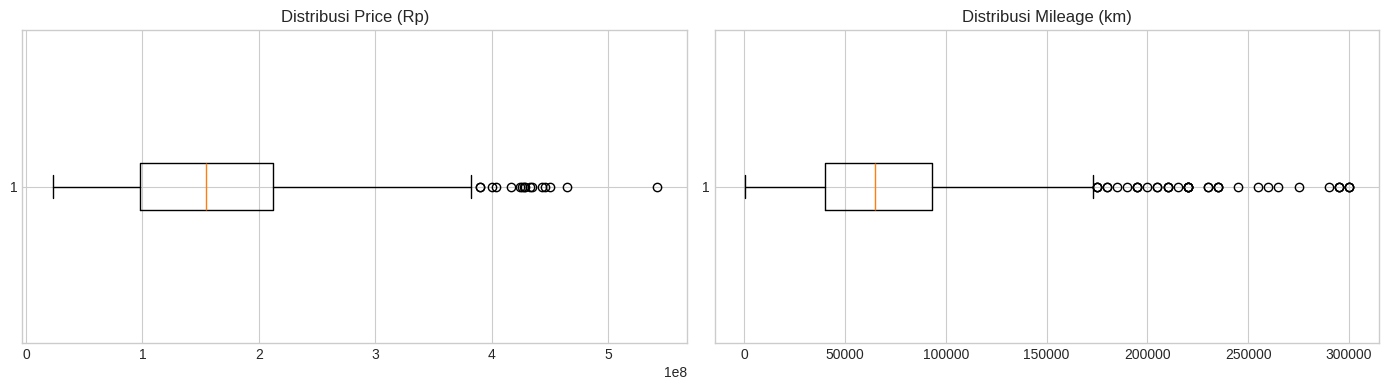


JUMLAH KATEGORI UNIK SETELAH REDUKSI (MIN_FREQ >= 5)
  brand          : 14 kategori unik
  car_model      : 67 kategori unik
  location       : 27 kategori unik
  transmission   : 2 kategori unik

Jumlah kolom df_rf (OHE)     : 117
Jumlah kolom df_boost (native): 11

Total Fitur RF (X_rf)           : 113 kolom
Total Fitur Boost (X_boost)     : 7 kolom
Kolom kategorikal untuk CatBoost: ['brand', 'location', 'transmission', 'car_model']

EKSPERIMEN PERBANDINGAN SPLIT RATIO (DATASET DEDUP)

  Split 60:40 | Train: 670 | Test: 448
    Random Forest      | R²=0.9051 | MAE=13,720,822 | RMSE=23,669,675
    LightGBM           | R²=0.8435 | MAE=18,578,872 | RMSE=30,393,486
    CatBoost           | R²=0.8584 | MAE=17,056,533 | RMSE=28,908,142

  Split 70:30 | Train: 782 | Test: 336
    Random Forest      | R²=0.9078 | MAE=12,641,143 | RMSE=22,547,580
    LightGBM           | R²=0.8419 | MAE=17,408,903 | RMSE=29,537,204
    CatBoost           | R²=0.8745 | MAE=16,000,742 | RMSE=26,317,823

  Spli

,Rata-rata R²,Rata-rata MAE (Rp),Rata-rata RMSE (Rp)
Split,,,
80:20,0.8941,14124745.0,23958625.0
70:30,0.8747,15350263.0,26134202.0
60:40,0.8690,16452076.0,27657101.0


Model,CatBoost,LightGBM,Random Forest,Rata-rata R²
Split,,,,
80:20,0.8877,0.8640,0.9307,0.8941
70:30,0.8745,0.8419,0.9078,0.8747
60:40,0.8584,0.8435,0.9051,0.8690



KESIMPULAN PEMILIHAN SPLIT RATIO
  80:20 : 0.8941 <- TERPILIH
  70:30 : 0.8747
  60:40 : 0.8690

RINGKASAN DATA FINAL (Split 80:20)
  Data Train : 894 sampel
  Data Test  : 224 sampel


In [ ]:
# =============================================================
# 3. DATA PREPARATION
# =============================================================
df_clean = df_raw.copy()

# ------------------- 3.1 Data Cleaning -------------------
df_clean['mileage (km)'] = (
    df_clean['mileage (km)']
    .astype(str)
    .str.replace(',', '', regex=False)
    .astype(float)
)

threshold_min_price = 10_000_000
df_clean = df_clean[df_clean['price (Rp)'] >= threshold_min_price].reset_index(drop=True)
df_clean = df_clean[df_clean['mileage (km)'] > 100].reset_index(drop=True)

print(f'\nJumlah baris setelah cleaning (price & mileage filter): {len(df_clean)}')

# ------------------- 3.1B Duplicate Removal (BARU) -------------------
# Duplikat semu diidentifikasi berdasarkan seluruh kolom KECUALI 'plate type',
# karena plate type (ganjil/genap) adalah atribut administratif yang tidak
# merepresentasikan perbedaan fisik kendaraan. Verifikasi price_nunique=1
# per grup mengonfirmasi ini duplikasi murni, bukan variasi harga yang sah.

cols_except_plate = [c for c in df_clean.columns if c != 'plate type']

dup_check = df_clean[df_clean.duplicated(subset=cols_except_plate, keep=False)] \
                .groupby(cols_except_plate)['price (Rp)'].nunique()
print(f"Distribusi price_nunique per grup duplikat:\n{dup_check.value_counts()}")

df_clean = df_clean.drop_duplicates(subset=cols_except_plate, keep='first').reset_index(drop=True)
df_clean = df_clean.drop(columns=['plate type'])  # sudah terbukti tidak reliable, di-drop total

print(f'Jumlah baris setelah dedup: {len(df_clean)}')
print(f'Kolom tersisa: {df_clean.columns.tolist()}')

# ------------------- 3.2 Visualisasi Outlier -------------------
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].boxplot(df_clean['price (Rp)'], vert=False)
ax[0].set_title('Distribusi Price (Rp)')
ax[1].boxplot(df_clean['mileage (km)'], vert=False)
ax[1].set_title('Distribusi Mileage (km)')
plt.tight_layout()
plt.show()

# ------------------- 3.3 Feature Extraction -------------------
df_clean['engine_cc'] = (
    df_clean['car name']
    .str.extract(r'(\d+\.\d+)$')[0]
    .astype(float) * 1000
)

df_clean['car_model'] = (
    df_clean['car name']
    .str.replace(r'\s+\d+\.\d+$', '', regex=True)
)

# ------------------- 3.4 Car Age -------------------
CURRENT_YEAR = 2026
df_clean['car_age'] = CURRENT_YEAR - df_clean['year']

# ------------------- 3.5 Reduksi Rare Categories -> "Other" -------------------
# CATATAN: plate type sudah di-drop, jadi tidak masuk categorical_cols lagi
MIN_FREQ = 5
categorical_cols = ['brand', 'car_model', 'location', 'transmission']

rare_values_mapping = {}
for col in categorical_cols:
    freq = df_clean[col].value_counts()
    rare_vals = freq[freq < MIN_FREQ].index.tolist()
    rare_values_mapping[col] = rare_vals
    df_clean[col] = df_clean[col].where(~df_clean[col].isin(rare_vals), other='Other')

print('\n' + '=' * 70)
print('JUMLAH KATEGORI UNIK SETELAH REDUKSI (MIN_FREQ >= 5)')
print('=' * 70)
for col in categorical_cols:
    print(f'  {col:<15}: {df_clean[col].nunique()} kategori unik')

# ------------------- 3.6 Dua Versi Dataset (Dual-Path Encoding) -------------------
# df_rf    -> OHE semua kolom kategorikal   -> untuk Random Forest
# df_boost -> native categorical dtype      -> untuk LightGBM & CatBoost

df_rf = pd.get_dummies(df_clean, columns=categorical_cols, dtype=int)

df_boost = df_clean.copy()
for col in categorical_cols:
    df_boost[col] = df_boost[col].astype('category')

print(f'\nJumlah kolom df_rf (OHE)     : {df_rf.shape[1]}')
print(f'Jumlah kolom df_boost (native): {df_boost.shape[1]}')

# ------------------- 3.7 Split Feature (X) & Target (y) -------------------
DROP_COLS = ['price (Rp)', 'car name', 'instalment (Rp|Monthly)', 'year']

X_rf = df_rf.drop(columns=DROP_COLS)
X_boost = df_boost.drop(columns=DROP_COLS)
y = df_clean['price (Rp)']

cat_feature_names = [col for col in X_boost.columns if X_boost[col].dtype.name == 'category']

print(f'\nTotal Fitur RF (X_rf)           : {X_rf.shape[1]} kolom')
print(f'Total Fitur Boost (X_boost)     : {X_boost.shape[1]} kolom')
print(f'Kolom kategorikal untuk CatBoost: {cat_feature_names}')

# =============================================================
# 3.8 EKSPERIMEN PEMILIHAN SPLIT RATIO
#     (60:40 vs 70:30 vs 80:20) — dataset sudah di-dedup
# =============================================================
split_candidates = {'60:40': 0.40, '70:30': 0.30, '80:20': 0.20}

default_models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'LightGBM': LGBMRegressor(n_estimators=100, random_state=42, verbose=-1),
    'CatBoost': CatBoostRegressor(iterations=100, random_seed=42, verbose=False),
}

results_split = []

print('\n' + '=' * 70)
print('EKSPERIMEN PERBANDINGAN SPLIT RATIO (DATASET DEDUP)')
print('=' * 70)

for split_name, test_size in split_candidates.items():
    X_tr_rf, X_te_rf, y_tr, y_te = train_test_split(X_rf, y, test_size=test_size, random_state=42)
    X_tr_b, X_te_b, _, _ = train_test_split(X_boost, y, test_size=test_size, random_state=42)

    print(f'\n  Split {split_name} | Train: {len(X_tr_rf)} | Test: {len(X_te_rf)}')

    for model_name, model_template in default_models.items():
        m = clone(model_template)

        if model_name == 'Random Forest':
            m.fit(X_tr_rf, y_tr)
            y_pred = m.predict(X_te_rf)
        elif model_name == 'LightGBM':
            m.fit(X_tr_b, y_tr, categorical_feature='auto')
            y_pred = m.predict(X_te_b)
        else:
            m.fit(X_tr_b, y_tr, cat_features=cat_feature_names)
            y_pred = m.predict(X_te_b)

        r2 = r2_score(y_te, y_pred)
        mae = mean_absolute_error(y_te, y_pred)
        rmse = np.sqrt(mean_squared_error(y_te, y_pred))

        results_split.append({'Split': split_name, 'Model': model_name,
                               'R²': round(r2, 4), 'MAE': round(mae, 0), 'RMSE': round(rmse, 0)})
        print(f'    {model_name:<18} | R²={r2:.4f} | MAE={mae:,.0f} | RMSE={rmse:,.0f}')

df_split_results = pd.DataFrame(results_split)

summary_table = df_split_results.groupby('Split').agg(
    Avg_R2=('R²', 'mean'), Avg_MAE=('MAE', 'mean'), Avg_RMSE=('RMSE', 'mean')
).round({'Avg_R2': 4, 'Avg_MAE': 0, 'Avg_RMSE': 0})
summary_table.columns = ['Rata-rata R²', 'Rata-rata MAE (Rp)', 'Rata-rata RMSE (Rp)']
display(summary_table.sort_values('Rata-rata R²', ascending=False))

pivot_r2 = df_split_results.pivot(index='Split', columns='Model', values='R²')
pivot_r2['Rata-rata R²'] = pivot_r2.mean(axis=1).round(4)
display(pivot_r2.sort_values('Rata-rata R²', ascending=False))

avg_r2_per_split = df_split_results.groupby('Split')['R²'].mean()
best_split_name = avg_r2_per_split.idxmax()
best_test_size = split_candidates[best_split_name]

print('\n' + '=' * 70)
print('KESIMPULAN PEMILIHAN SPLIT RATIO')
print('=' * 70)
for spl, r2_val in avg_r2_per_split.sort_values(ascending=False).items():
    marker = ' <- TERPILIH' if spl == best_split_name else ''
    print(f'  {spl} : {r2_val:.4f}{marker}')

# --- Split Final ---
X_train_rf, X_test_rf, y_train, y_test = train_test_split(X_rf, y, test_size=best_test_size, random_state=42)
X_train_boost, X_test_boost, _, _ = train_test_split(X_boost, y, test_size=best_test_size, random_state=42)

print(f'\nRINGKASAN DATA FINAL (Split {best_split_name})')
print(f'  Data Train : {X_train_rf.shape[0]} sampel')
print(f'  Data Test  : {X_test_rf.shape[0]} sampel')

---
## 🤖 TAHAP 4: MODELING (HYPERPARAMETER TUNING)
Tujuan: Melatih dan mengoptimalkan 3 algoritma Ensemble Learning (Random Forest, LightGBM, CatBoost) menggunakan 5-Fold Cross Validation & GridSearchCV.

In [ ]:
# =============================================================
# 4. MODELING & HYPERPARAMETER TUNING
# =============================================================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# --- Random Forest ---
param_rf = {'n_estimators': [100, 200], 'max_depth': [10, 15, None], 'min_samples_split': [2, 5]}
grid_rf = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), param_rf,
                        cv=kf, scoring='r2', n_jobs=-1, return_train_score=True)
grid_rf.fit(X_train_rf, y_train)
best_rf = grid_rf.best_estimator_
print(f'\n[1/3] Random Forest | Best Params: {grid_rf.best_params_} | Best CV R²: {grid_rf.best_score_:.4f}')

# --- LightGBM ---
param_lgb = {'n_estimators': [50, 100, 150], 'learning_rate': [0.05, 0.1],
             'max_depth': [3, 5, 7], 'num_leaves': [15, 31]}
grid_lgb = GridSearchCV(LGBMRegressor(random_state=42, verbose=-1), param_lgb,
                         cv=kf, scoring='r2', n_jobs=-1, return_train_score=True)
grid_lgb.fit(X_train_boost, y_train, categorical_feature='auto')
best_lgb = grid_lgb.best_estimator_
print(f'[2/3] LightGBM | Best Params: {grid_lgb.best_params_} | Best CV R²: {grid_lgb.best_score_:.4f}')

# --- CatBoost (Optimized) ---
param_cat = {'iterations': [300, 500, 800], 'learning_rate': [0.03, 0.05, 0.1],
             'depth': [6, 8], 'l2_leaf_reg': [3, 5]}
grid_cat = GridSearchCV(
    CatBoostRegressor(random_seed=42, verbose=False, one_hot_max_size=15),
    param_cat, cv=kf, scoring='r2', n_jobs=-1, return_train_score=True
)
grid_cat.fit(X_train_boost, y_train, cat_features=cat_feature_names)
best_cat = grid_cat.best_estimator_
print(f'[3/3] CatBoost | Best Params: {grid_cat.best_params_} | Best CV R²: {grid_cat.best_score_:.4f}')


[1/3] Random Forest | Best Params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100} | Best CV R²: 0.8797
[2/3] LightGBM | Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 150, 'num_leaves': 15} | Best CV R²: 0.8632
[3/3] CatBoost | Best Params: {'depth': 8, 'iterations': 500, 'l2_leaf_reg': 3, 'learning_rate': 0.03} | Best CV R²: 0.8775


---
## 📈 TAHAP 5: EVALUATION & FEATURE IMPORTANCE
Tujuan: Menguji performa ketiga model pada Data Uji (Test Set), menyusun tabel perbandingan metrik (MAE, RMSE, R²), dan menvisualisasikan 20 fitur paling berpengaruh.

In [ ]:
# =============================================================
# 5. EVALUASI MODEL
# =============================================================
pred_rf = best_rf.predict(X_test_rf)
pred_lgb = best_lgb.predict(X_test_boost)
pred_cat = best_cat.predict(X_test_boost)

def get_metrics(y_true, y_pred, name):
    return {"Model": name,
            "MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
            "R²": r2_score(y_true, y_pred)}

results = [
    get_metrics(y_test, pred_rf, "Random Forest (Tuned)"),
    get_metrics(y_test, pred_lgb, "LightGBM (Tuned)"),
    get_metrics(y_test, pred_cat, "CatBoost (Tuned)"),
]
df_results = pd.DataFrame(results).sort_values(by="R²", ascending=False).reset_index(drop=True)

def format_rupiah(x):
    return f"Rp {x:,.0f}"

df_display = df_results.copy()
df_display["MAE"] = df_display["MAE"].apply(format_rupiah)
df_display["RMSE"] = df_display["RMSE"].apply(format_rupiah)
df_display["R²"] = df_display["R²"].map(lambda v: f"{v:.4f}")

print('\n' + '=' * 70)
print('TABEL EVALUASI MODEL FINAL (DATASET DEDUP)')
print('=' * 70)
display(df_display)

# --- Overfitting Gap (Train R² - Test R²) ---
gap_rf = r2_score(y_train, best_rf.predict(X_train_rf)) - r2_score(y_test, pred_rf)
gap_lgb = r2_score(y_train, best_lgb.predict(X_train_boost)) - r2_score(y_test, pred_lgb)
gap_cat = r2_score(y_train, best_cat.predict(X_train_boost)) - r2_score(y_test, pred_cat)

print(f'\nGap RF      : {gap_rf:.4f}')
print(f'Gap LightGBM: {gap_lgb:.4f}')
print(f'Gap CatBoost: {gap_cat:.4f}')

# --- CV Std Consistency ---
std_rf = grid_rf.cv_results_['std_test_score'][grid_rf.best_index_]
std_lgb = grid_lgb.cv_results_['std_test_score'][grid_lgb.best_index_]
std_cat = grid_cat.cv_results_['std_test_score'][grid_cat.best_index_]

print(f'\nCV Std RF      : {std_rf:.4f}')
print(f'CV Std LightGBM: {std_lgb:.4f}')
print(f'CV Std CatBoost: {std_cat:.4f}')

# =============================================================
# CATATAN PENTING:
# Visualisasi Dibuat Terpisah Guna Merapihakan Output
# =============================================================


TABEL EVALUASI MODEL FINAL (DATASET DEDUP)


,Model,MAE,RMSE,R²
0,Random Forest (Tuned),"Rp 11,272,162","Rp 19,627,556",0.9303
1,CatBoost (Tuned),"Rp 13,744,042","Rp 22,486,865",0.9085
2,LightGBM (Tuned),"Rp 15,716,846","Rp 25,939,547",0.8782



Gap RF      : 0.0450
Gap LightGBM: 0.0453
Gap CatBoost: 0.0416

CV Std RF      : 0.0262
CV Std LightGBM: 0.0241
CV Std CatBoost: 0.0271


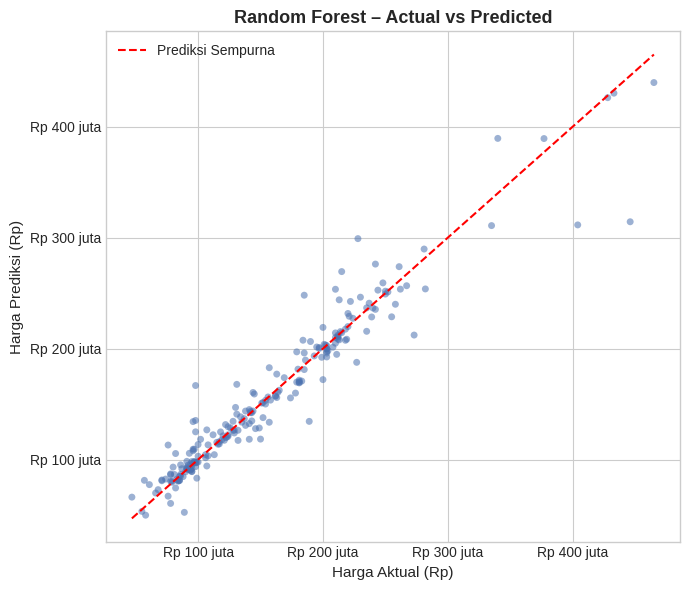

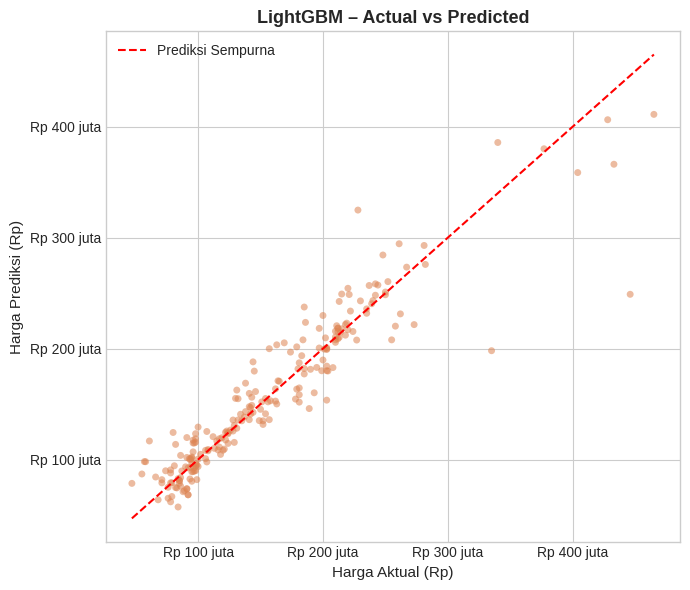

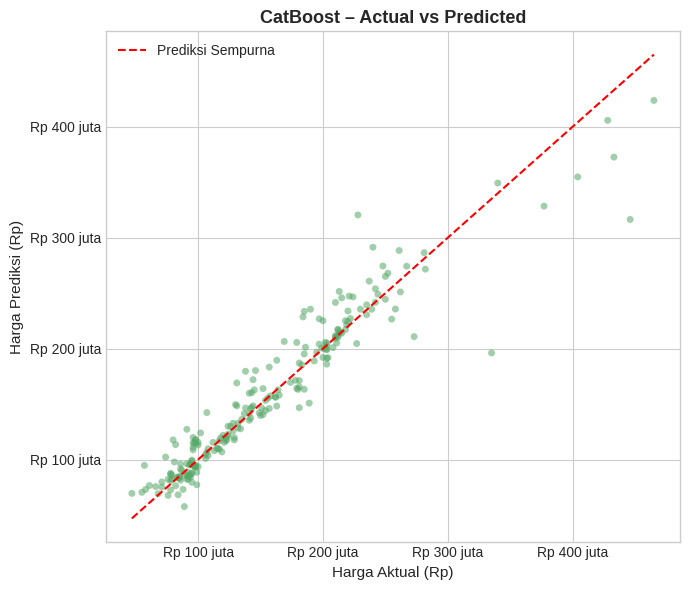

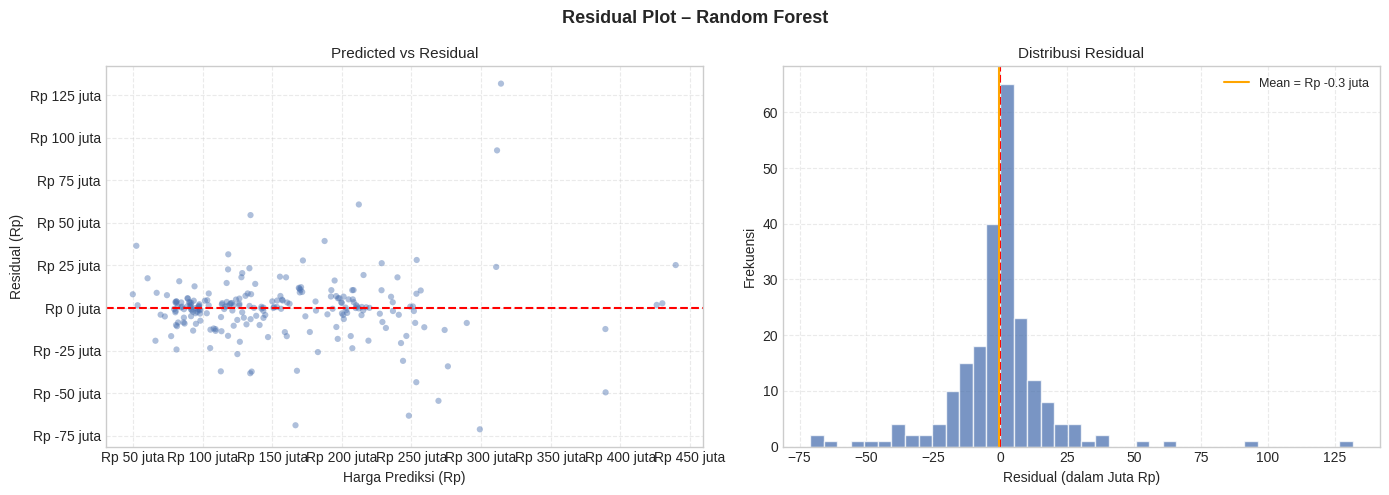

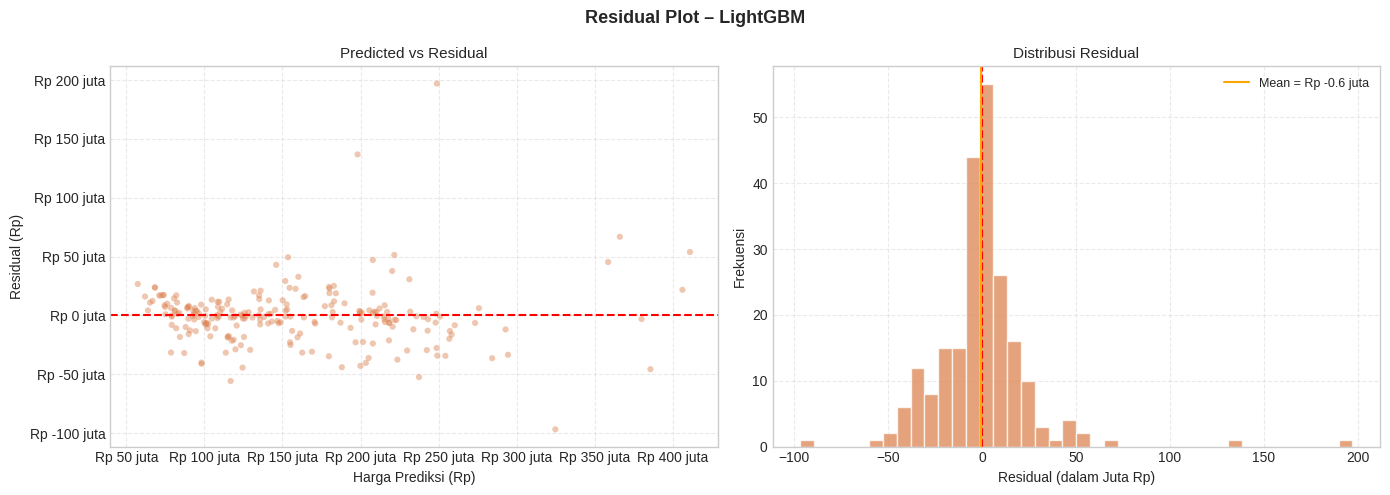

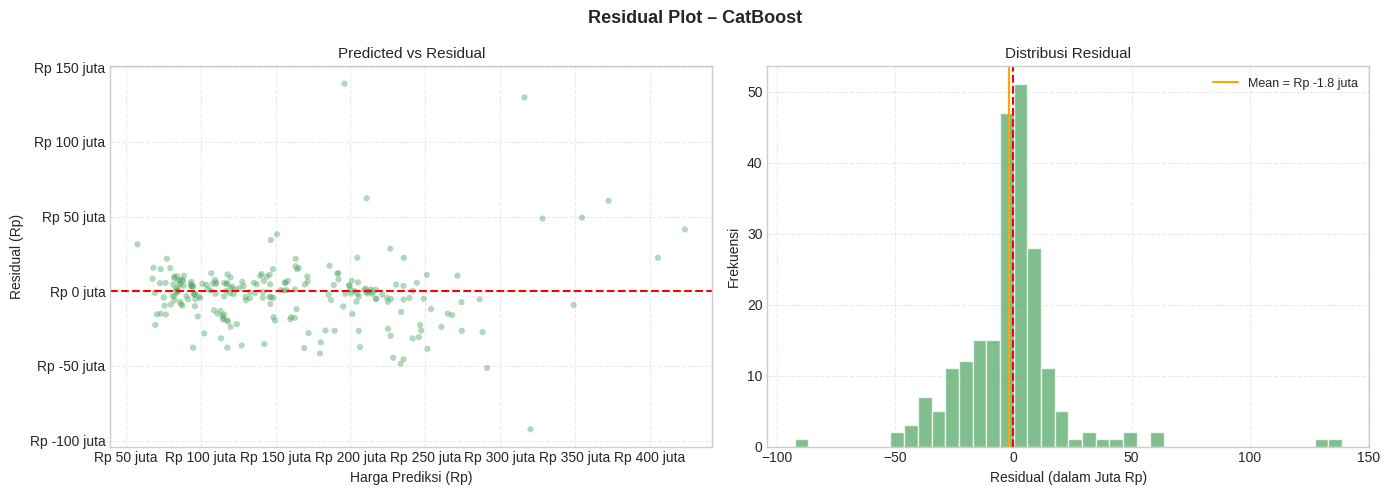

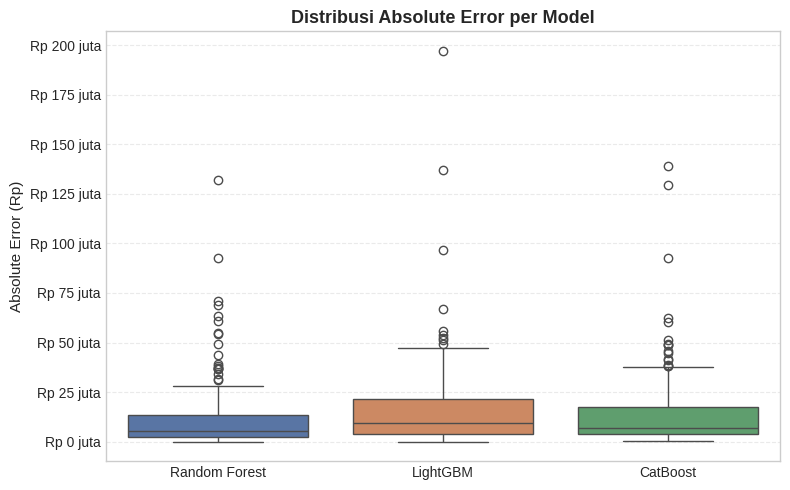

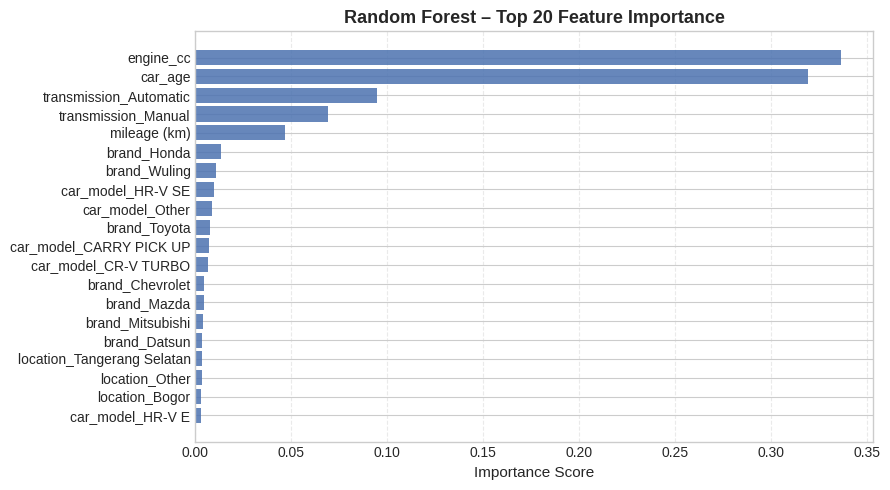

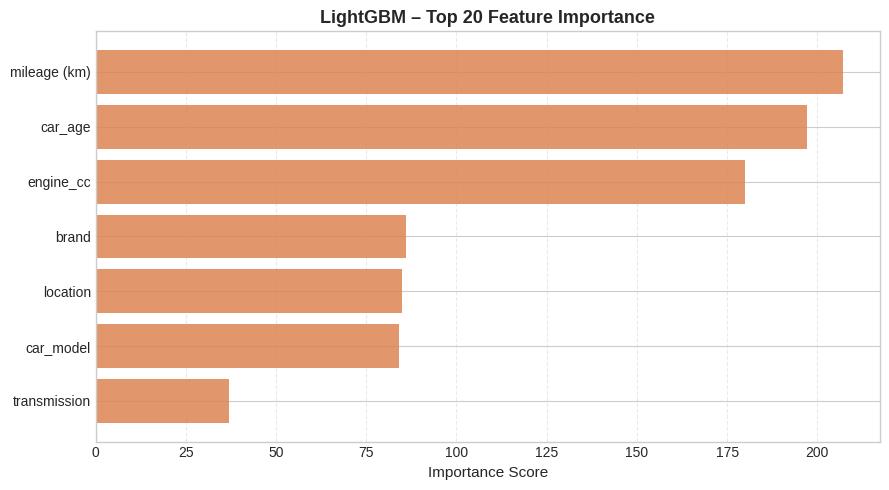

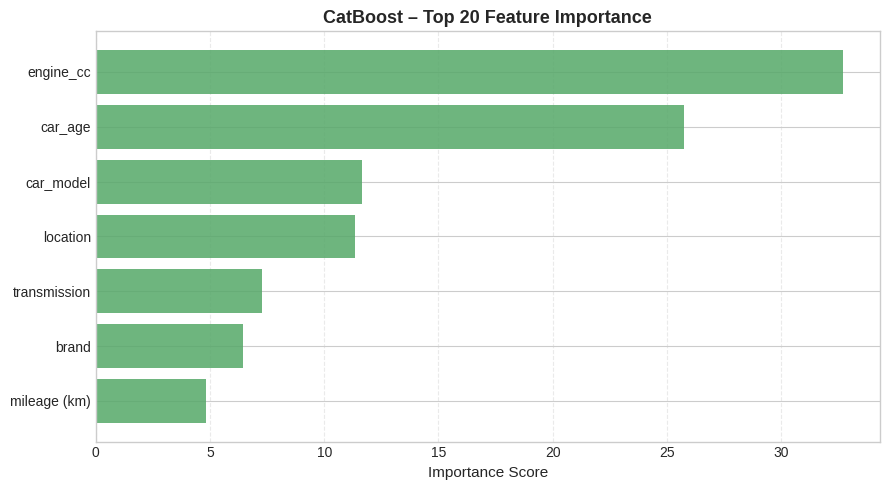

Memproses Learning Curve – Random Forest...


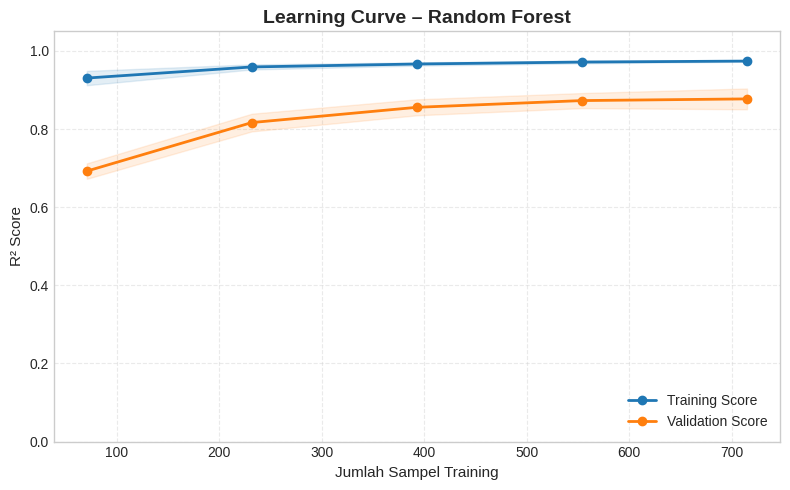

Memproses Learning Curve – LightGBM...


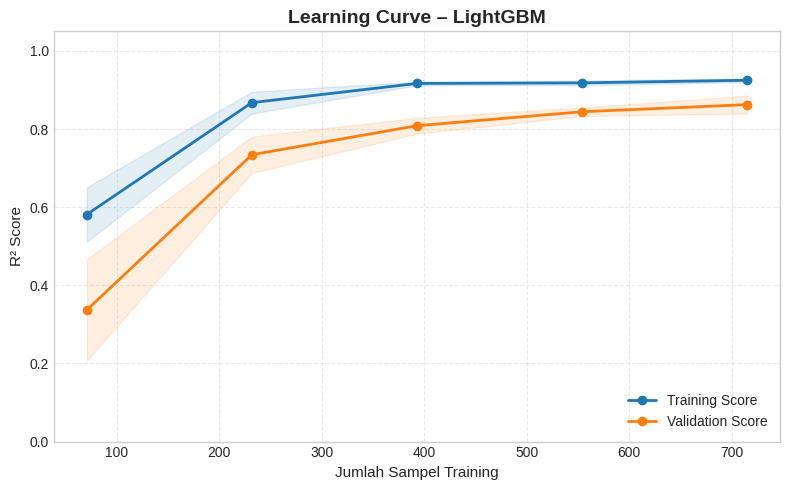

Memproses Learning Curve – CatBoost...


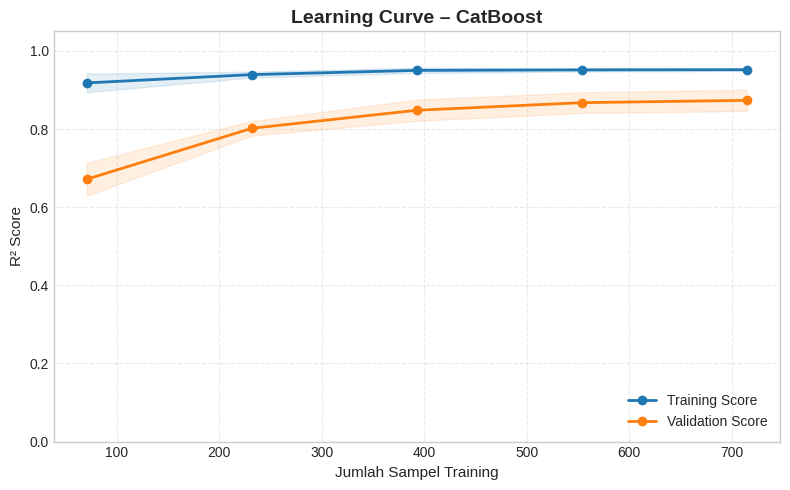


PAIRED T-TEST: RANDOM FOREST vs CATBOOST (Absolute Error)
T-statistic : -2.5110
P-value     : 0.0127
-> Perbedaan signifikan secara statistik (p < 0.05)


In [ ]:
# =============================================================
# VISUALISASI EVALUASI MODEL — SAMBUNGAN DARI pipeline_full_dedup.py
# =============================================================
# Jalankan file ini SETELAH pipeline_full_dedup.py selesai dijalankan
# di sesi Colab yang sama, karena variabel berikut harus sudah ada:
# best_rf, best_lgb, best_cat, X_train_rf, X_train_boost,
# X_test_rf, X_test_boost, y_train, y_test,
# pred_rf, pred_lgb, pred_cat, cat_feature_names, kf
# =============================================================

# =============================================================
# 5.5 Scatter Plot – Actual vs Predicted
# =============================================================
def scatter_actual_vs_pred(y_true, y_pred, title, color='#4C72B0'):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    max_val = max(y_true.max(), y_pred.max())
    min_val = min(y_true.min(), y_pred.min())

    plt.figure(figsize=(7, 6))
    plt.scatter(y_true, y_pred, alpha=0.55, edgecolors='none', s=25, color=color)
    plt.plot([min_val, max_val], [min_val, max_val],
             'r--', linewidth=1.5, label='Prediksi Sempurna')
    plt.title(title, fontsize=13, fontweight='bold')
    plt.xlabel('Harga Aktual (Rp)', fontsize=11)
    plt.ylabel('Harga Prediksi (Rp)', fontsize=11)
    plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'Rp {v/1e9:.1f} miliar' if v >= 1e9 else f'Rp {v/1e6:.0f} juta'))
    plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'Rp {v/1e9:.1f} miliar' if v >= 1e9 else f'Rp {v/1e6:.0f} juta'))
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

scatter_actual_vs_pred(y_test, pred_rf,  "Random Forest – Actual vs Predicted", color='#4C72B0')
scatter_actual_vs_pred(y_test, pred_lgb, "LightGBM – Actual vs Predicted",      color='#DD8452')
scatter_actual_vs_pred(y_test, pred_cat, "CatBoost – Actual vs Predicted",       color='#55A868')

# =============================================================
# 5.6 Residual Plot
# =============================================================
def plot_residual(y_true, y_pred, title, color='#4C72B0'):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    residuals = y_true - y_pred

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    axes[0].scatter(y_pred, residuals, alpha=0.45, edgecolors='none', s=20, color=color)
    axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
    axes[0].set_xlabel('Harga Prediksi (Rp)', fontsize=10)
    axes[0].set_ylabel('Residual (Rp)', fontsize=10)
    axes[0].set_title('Predicted vs Residual', fontsize=11)
    axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'Rp {v/1e9:.1f} miliar' if v >= 1e9 else f'Rp {v/1e6:.0f} juta'))
    axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'Rp {v/1e9:.1f} miliar' if v >= 1e9 else f'Rp {v/1e6:.0f} juta'))
    axes[0].grid(linestyle='--', alpha=0.4)

    axes[1].hist(residuals / 1e6, bins=40, color=color, alpha=0.75, edgecolor='white')
    axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
    axes[1].axvline(np.mean(residuals) / 1e6, color='orange', linestyle='-', linewidth=1.5,
                    label=f'Mean = Rp {np.mean(residuals)/1e6:.1f} juta')
    axes[1].set_xlabel('Residual (dalam Juta Rp)', fontsize=10)
    axes[1].set_ylabel('Frekuensi', fontsize=10)
    axes[1].set_title('Distribusi Residual', fontsize=11)
    axes[1].legend(fontsize=9)
    axes[1].grid(linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

plot_residual(y_test, pred_rf,  "Residual Plot – Random Forest", color='#4C72B0')
plot_residual(y_test, pred_lgb, "Residual Plot – LightGBM",      color='#DD8452')
plot_residual(y_test, pred_cat, "Residual Plot – CatBoost",       color='#55A868')

# =============================================================
# 5.7 Boxplot Distribusi Absolute Error per Model
# =============================================================
abs_err_rf  = np.abs(y_test - pred_rf)
abs_err_lgb = np.abs(y_test - pred_lgb)
abs_err_cat = np.abs(y_test - pred_cat)

df_err = pd.DataFrame({
    "Random Forest": abs_err_rf,
    "LightGBM"     : abs_err_lgb,
    "CatBoost"     : abs_err_cat,
})

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_err, palette=['#4C72B0', '#DD8452', '#55A868'])
plt.title("Distribusi Absolute Error per Model", fontsize=13, fontweight='bold')
plt.ylabel("Absolute Error (Rp)", fontsize=11)
plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda v, _: f'Rp {v/1e9:.1f} miliar' if v >= 1e9 else f'Rp {v/1e6:.0f} juta')
)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# =============================================================
# 5.8 Feature Importance – Top 20
# =============================================================
def plot_importance(model, feature_names, title, color='#4C72B0', top_n=20):
    df_imp = (
        pd.DataFrame({"Feature": feature_names, "Importance": model.feature_importances_})
        .sort_values("Importance", ascending=False)
        .head(top_n)
    )
    plt.figure(figsize=(9, 5))
    plt.barh(df_imp["Feature"], df_imp["Importance"], color=color, alpha=0.85)
    plt.gca().invert_yaxis()
    plt.title(title, fontsize=13, fontweight='bold')
    plt.xlabel("Importance Score", fontsize=11)
    plt.grid(axis='x', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

# CATATAN: X_train_rf.columns sekarang beda dari versi lama karena
# plate type sudah tidak ada dan jumlah kategori rare berubah.
plot_importance(best_rf,  X_train_rf.columns,    "Random Forest – Top 20 Feature Importance", color='#4C72B0')
plot_importance(best_lgb, X_train_boost.columns, "LightGBM – Top 20 Feature Importance",      color='#DD8452')
plot_importance(best_cat, X_train_boost.columns, "CatBoost – Top 20 Feature Importance",       color='#55A868')

# =============================================================
# 5.9 Learning Curve – Deteksi Overfitting / Underfitting
# =============================================================
def plot_learning_curve(estimator, title, X, y, cv=5, n_jobs=-1, is_catboost=False):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y,
        cv=cv,
        n_jobs=n_jobs,
        train_sizes=np.linspace(0.1, 1.0, 5),
        scoring='r2',
        shuffle=True,
        random_state=42,
        fit_params={'cat_features': cat_feature_names} if is_catboost else None
    )

    train_mean = np.mean(train_scores, axis=1)
    test_mean  = np.mean(test_scores,  axis=1)
    train_std  = np.std(train_scores,  axis=1)
    test_std   = np.std(test_scores,   axis=1)

    plt.figure(figsize=(8, 5))
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Jumlah Sampel Training", fontsize=11)
    plt.ylabel("R² Score", fontsize=11)
    plt.grid(linestyle='--', alpha=0.4)

    plt.plot(train_sizes, train_mean, 'o-', color='#1f77b4', linewidth=2, markersize=6, label="Training Score")
    plt.plot(train_sizes, test_mean,  'o-', color='#ff7f0e', linewidth=2, markersize=6, label="Validation Score")

    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.12, color='#1f77b4')
    plt.fill_between(train_sizes, test_mean  - test_std,  test_mean  + test_std,  alpha=0.12, color='#ff7f0e')

    plt.legend(loc='lower right', fontsize=10)
    plt.ylim(min(0, test_mean.min() - 0.08), 1.05)
    plt.tight_layout()
    plt.show()

print("Memproses Learning Curve – Random Forest...")
plot_learning_curve(best_rf,  "Learning Curve – Random Forest", X_train_rf, y_train, cv=kf)

print("Memproses Learning Curve – LightGBM...")
plot_learning_curve(best_lgb, "Learning Curve – LightGBM",      X_train_boost, y_train, cv=kf)

print("Memproses Learning Curve – CatBoost...")
plot_learning_curve(best_cat, "Learning Curve – CatBoost",      X_train_boost, y_train, cv=kf, is_catboost=True)

# =============================================================
# 5.10 Paired t-test — Random Forest vs CatBoost
# =============================================================
# Membandingkan apakah selisih performa RF vs CatBoost signifikan
# secara statistik, atau hanya variasi acak dari satu kali split.
# Menggunakan absolute error per baris data test sebagai basis
# perbandingan berpasangan (paired), karena kedua model dievaluasi
# pada baris data test yang identik (index sama).
from scipy import stats

# Pastikan index y_test, pred_rf, pred_cat sejajar (baris sama)
abs_err_rf_arr  = np.abs(y_test.values - pred_rf)
abs_err_cat_arr = np.abs(y_test.values - pred_cat)

t_stat, p_value = stats.ttest_rel(abs_err_rf_arr, abs_err_cat_arr)

print('\n' + '=' * 70)
print('PAIRED T-TEST: RANDOM FOREST vs CATBOOST (Absolute Error)')
print('=' * 70)
print(f'T-statistic : {t_stat:.4f}')
print(f'P-value     : {p_value:.4f}')
if p_value < 0.05:
    print('-> Perbedaan signifikan secara statistik (p < 0.05)')
else:
    print('-> Perbedaan TIDAK signifikan secara statistik (p >= 0.05)')

---
## 💾 TAHAP 6: DEPLOYMENT (PENYIMPANAN MODEL)
Tujuan: Menyimpan model terbaik (CatBoost `.cbm`) dan daftar fitur (`feature_names.pkl`) untuk kebutuhan implementasi aplikasi web/deployment.

In [ ]:
# Tambahkan di Tahap 6 (Deployment/Saving) pada training notebook
from joblib import dump

dump(best_rf, "rf_model_rev3.pkl")
dump(X_rf.columns.tolist(), "feature_names_rev3.pkl")
dump(rare_values_mapping, "rare_values_mapping3.pkl")

print("✅ Model, feature names, & rare_values_mapping berhasil disimpan.")

✅ Model, feature names, & rare_values_mapping berhasil disimpan.
